# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [5]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [6]:
df.shape

(17379, 17)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [9]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Target leakage és irreleváns oszlopok eltávolítása
features_to_drop = ['instant', 'dteday', 'casual', 'registered']
X_train_cleaned = X_train.drop(columns=features_to_drop, errors='ignore')
X_test_cleaned = X_test.drop(columns=features_to_drop, errors='ignore')

# Kategóriás és numerikus oszlopok meghatározása
cat_features = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
num_features = ['temp', 'atemp', 'hum', 'windspeed', 'yr', 'holiday', 'workingday']

# Preprocessing Pipeline (One-Hot Encoding a kategóriáknak, Scaling a numerikusoknak)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

# Adatok transzformálása
X_train_prep = preprocessor.fit_transform(X_train_cleaned)
X_test_prep = preprocessor.transform(X_test_cleaned)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [13]:
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [14]:
# --- Lineáris Regresszió (Ridge L2 regulációval) ---
lr_pipeline = Pipeline([
    ('model', Ridge())
])

param_grid_lr = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0]
}

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lr.fit(X_train_prep, y_train)

best_lr_model = grid_lr.best_estimator_
print(f"Best Linear Regression Params: {grid_lr.best_params_}")


# --- XGBoost Regressor ---
xgb_model = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train_prep, y_train)

best_xgb_model = grid_xgb.best_estimator_
print(f"Best XGBoost Params: {grid_xgb.best_params_}")

Best Linear Regression Params: {'model__alpha': 0.1}
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}


## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Predikciók
y_pred_lr = best_lr_model.predict(X_test_prep)
y_pred_xgb = best_xgb_model.predict(X_test_prep)

# Értékelési metrikák
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- MODEL PERFORMANCE ---")
print(f"Linear Regression -> MSE: {mse_lr:.2f}, R2: {r2_lr:.4f}")
print(f"XGBoost Regressor -> MSE: {mse_xgb:.2f}, R2: {r2_xgb:.4f}")


--- MODEL PERFORMANCE ---
Linear Regression -> MSE: 10088.42, R2: 0.6814
XGBoost Regressor -> MSE: 2303.49, R2: 0.9273


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

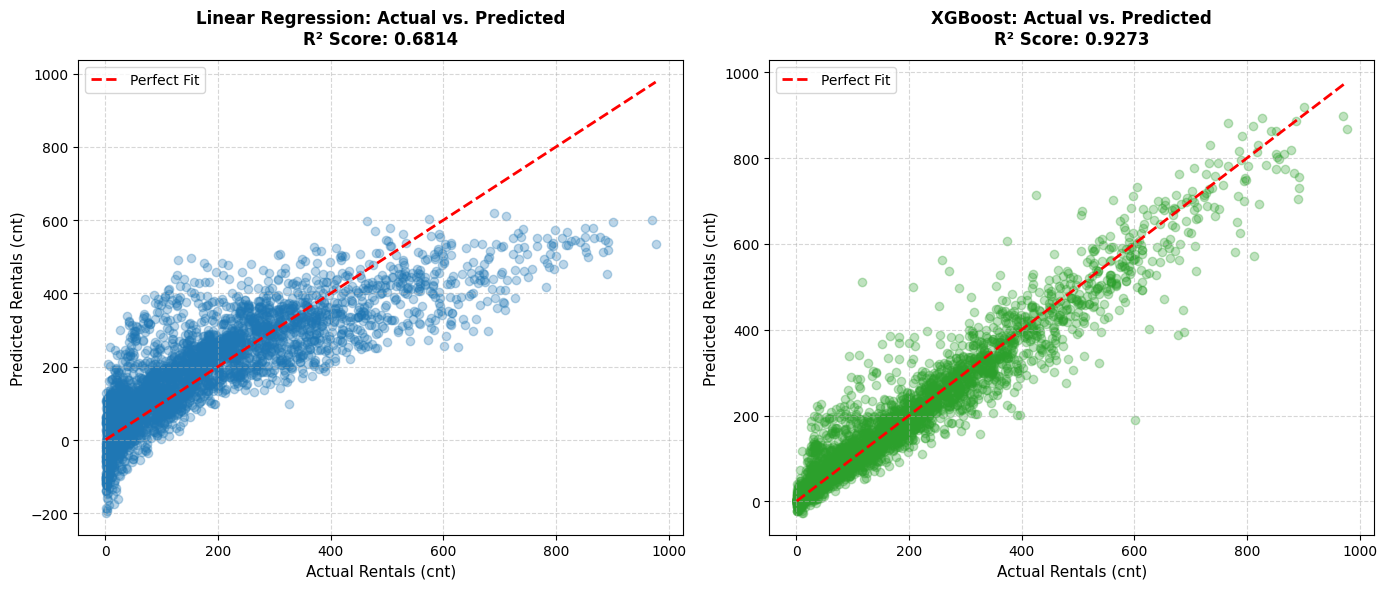

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# R² értékek kiszámítása
r2_lr = r2_score(y_test, y_pred_lr)
r2_xgb = r2_score(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Diagram: Lineáris Regresszió
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='tab:blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Rentals (cnt)', fontsize=11)
axes[0].set_ylabel('Predicted Rentals (cnt)', fontsize=11)
axes[0].set_title(f'Linear Regression: Actual vs. Predicted\nR² Score: {r2_lr:.4f}', fontsize=12, fontweight='bold', pad=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Diagram: XGBoost
axes[1].scatter(y_test, y_pred_xgb, alpha=0.3, color='tab:green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Rentals (cnt)', fontsize=11)
axes[1].set_ylabel('Predicted Rentals (cnt)', fontsize=11)
axes[1].set_title(f'XGBoost: Actual vs. Predicted\nR² Score: {r2_xgb:.4f}', fontsize=12, fontweight='bold', pad=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()